# Evaluación 1: Calidad, EDA y Preparación de Datos

**Integrantes:** Renato Acosta, Bruno Aldana, Alanis Figueroa, Benjamin Jara.                       
**Fecha de Creación:** Septiembre de 2026  
**Versión:** 1.0  

---

## Descripción
_Desarrollo de un proceso reproducible de diagnóstico de calidad, análisis exploratorio (EDA), resolución de preguntas de investigación y preparación de datos mediante Scikit-Learn Pipeline / ColumnTransformer._

---

## Objetivo
Diagnosticar problemas de calidad (duplicados, nulos, inconsistencias y outliers), responder a las preguntas de negocio planteadas y construir un pipeline de transformación reproducible para generar el dataset limpio final.

---

## Requisitos de Software
- `pandas` (= 2.2.3)
- `numpy` (= 2.1.3)
- `matplotlib` (= 3.10.0)
- `seaborn` (= 0.13.2)
- `scikit-learn` (= 1.6.1)

# Fuente de datos

In [ ]:
# Carga de datos local o por enlace
import pandas as pd
import numpy as np

# 1. Intentar descargar el archivo usando wget (URL del repositorio/entorno del curso).
#    Si la descarga falla (ej. sin acceso a internet, enlace vencido, error 403/404),
#    se conserva el archivo local ya presente en la carpeta del proyecto, evitando que
#    un wget fallido sobrescriba el CSV con un archivo vacío.
import os

url = "https://adecca.ubiobio.cl/file/download/eyJub21icmUiOiJyZW5kaW1pZW50b19hY2FkZW1pY29fZXZhbHVhY2lvbi5jc3YiLCJhcmNoaXZvIjoiMTc4ODAxMzQ1MDE0MDA3NC5jc3YiLCJwYXRoIjoiMjAyNlwvY3Vyc29zXC85OTEwNlwvNTI0NTg0XC8xNzg4MDEzNDUwMTQwMDc0LmNzdiJ9"
archivo_destino = "rendimiento_academico_evaluacion.csv"
archivo_temporal = "_descarga_tmp.csv"

get_ipython().system(f'wget -q -O {archivo_temporal} "{url}"')

if os.path.exists(archivo_temporal) and os.path.getsize(archivo_temporal) > 0:
    os.replace(archivo_temporal, archivo_destino)
    print(f"Descarga exitosa: '{archivo_destino}' actualizado desde el enlace.")
else:
    if os.path.exists(archivo_temporal):
        os.remove(archivo_temporal)
    print(f"No fue posible descargar desde el enlace (sin acceso o enlace no disponible); "
          f"se utiliza el archivo local '{archivo_destino}' ya presente en el entorno.")

# 2. Cargar el archivo (recién descargado o local)
data = pd.read_csv(archivo_destino)

print("Dimensiones del set de datos:", data.shape)
data.head()


Descarga exitosa: 'rendimiento_academico_evaluacion.csv' actualizado desde el enlace.
Dimensiones del set de datos: (5100, 11)


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


# Contexto de negocio
El conjunto de datos contiene información sociodemográfica, hábitos de estudio y antecedentes académicos de estudiantes de educación superior. El objetivo es analizar los factores que inciden en su rendimiento final (`FinalGrade`) y dejar un conjunto de datos limpio y procesado para modelos analíticos posteriores.

# Metadata

La siguiente tabla está **alineada con el archivo `Metadata.md` entregado por la profesora** (columnas `Variable`, `Rol`, `Tipo`, `Descripción`). Se añaden dos columnas adicionales (`Naturaleza/Escala` y `Reglas/Restricciones`) para dejar explícitas las reglas de dominio que se usarán en el diagnóstico (sección 1) y en el pipeline (sección 4); cuando la metadata oficial no especifica un límite numérico exacto, se indica como **supuesto operativo del equipo** (no contradice la metadata, solo la complementa).

| Variable | Rol (Metadata.md) | Tipo (Metadata.md) | Naturaleza / Escala | Descripción de Negocio (Metadata.md) | Reglas / Restricciones |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **`StudentID`** | Identificador | Categórica | Nominal | Identificador del estudiante | Estructura `STU-XXXXX`. |
| **`Age`** | Feature | Numérica | Numérica Discreta | Edad | Rango operativo lógico: 18 a 85 años *(supuesto del equipo; la metadata no especifica límites)*. |
| **`StudyHours`** | Feature | Numérica | Numérica Continua | Horas semanales de estudio | Valores ≥ 0; se asume un máximo lógico de 168 h/semana (7 días × 24 h) *(supuesto del equipo)*. |
| **`Attendance`** | Feature | Numérica | Numérica Continua | Porcentaje de asistencia | Rango teórico válido: [0.0, 100.0]% *(por ser porcentaje)*. |
| **`PreviousGPA`** | Feature | Numérica | Numérica Continua | Promedio académico previo **(escala de 1 a 10)** | **Escala oficial [1.0, 10.0]**, según `Metadata.md`. |
| **`AssignmentsCompleted`** | Feature | Numérica | Numérica Continua | Porcentaje de tareas completadas | Rango teórico válido: [0.0, 100.0]% *(por ser porcentaje)*. |
| **`SleepHours`** | Feature | Numérica | Numérica Continua | Horas de sueño diarias | Valores ≥ 0; se asume un máximo lógico de 24 h/día *(supuesto del equipo, por ser variable diaria)*. |
| **`InternetHours`** | Feature | Numérica | Numérica Continua | Horas diarias de uso de Internet | Valores ≥ 0; se asume un máximo lógico de 24 h/día *(supuesto del equipo, por ser variable diaria)*. |
| **`Scholarship`** | Feature | Categórica | Nominal | Tenencia de beca | Valores esperados: `Sí` / `No`. |
| **`Program`** | Feature | Categórica | Nominal | Programa académico | 5 carreras principales. |
| **`FinalGrade`** | Target | Numérica | Numérica Continua | Calificación final **(escala de 1 a 10)** | **Escala oficial [1.0, 10.0]**, según `Metadata.md`. |

**Nota importante:** en una versión previa de este notebook se asumió por error una escala chilena de notas [1.0, 7.0] para `PreviousGPA` y `FinalGrade`. Esa suposición **contradecía la metadata oficial** (`Metadata.md`, entregada por la profesora, que indica explícitamente "escala de 1 a 10" para ambas variables) y ha sido corregida en todas las secciones de este notebook, para que exista coherencia total entre el diagnóstico (sección 1), el EDA (sección 2), el tratamiento (sección 3), el pipeline (sección 4) y la verificación final (sección 5).


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# 1. Diagnóstico de calidad

## 1.1 Caracterización del dataset

In [ ]:
print(data.info())
print("\nRegistros totales:", data.shape[0])
print("Variables totales:", data.shape[1])
print("Variable Identificador: StudentID")
print("Variable Objetivo (Rendimiento): FinalGrade")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             5100 non-null   object 
 1   Age                   4997 non-null   float64
 2   StudyHours            4919 non-null   float64
 3   Attendance            4876 non-null   float64
 4   PreviousGPA           4938 non-null   float64
 5   AssignmentsCompleted  4884 non-null   float64
 6   SleepHours            4978 non-null   float64
 7   InternetHours         4924 non-null   float64
 8   Scholarship           5019 non-null   object 
 9   Program               5030 non-null   object 
 10  FinalGrade            5100 non-null   float64
dtypes: float64(8), object(3)
memory usage: 438.4+ KB
None

Registros totales: 5100
Variables totales: 11
Variable Identificador: StudentID
Variable Objetivo (Rendimiento): FinalGrade


## 1.2 Valores faltantes

In [ ]:
null_summary = pd.DataFrame({
    "Nulos_Absolutos": data.isnull().sum(),
    "Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
})
print(null_summary[null_summary["Nulos_Absolutos"] > 0].sort_values(by="Nulos_Absolutos", ascending=False))
print("Variables con mayor cantidad de datos faltantes: Attendance y AssignmentsCompleted")

                      Nulos_Absolutos  Porcentaje_Nulos
Attendance                        224              4.39
AssignmentsCompleted              216              4.24
StudyHours                        181              3.55
InternetHours                     176              3.45
PreviousGPA                       162              3.18
SleepHours                        122              2.39
Age                               103              2.02
Scholarship                        81              1.59
Program                            70              1.37
Variables con mayor cantidad de datos faltantes: Attendance y AssignmentsCompleted


### 1.2.1 Tratamiento de faltantes

Las variables con mayor cantidad de datos faltantes son `Attendance` (224 registros, 4.39%) y `AssignmentsCompleted` (216 registros, 4.24%), seguidas de `StudyHours` (181, 3.55%), `InternetHours` (176, 3.45%), `PreviousGPA` (162, 3.18%), `SleepHours` (122, 2.39%), `Age` (103, 2.02%), `Scholarship` (81, 1.59%) y `Program` (70, 1.37%). `StudentID` y `FinalGrade` no presentan valores nulos.

En ningún caso el porcentaje de faltantes supera el 5% de los registros, por lo que **no se justifica eliminar filas completas**: se perdería información y se introduciría un posible sesgo de selección. La estrategia definida es:

- **Variables numéricas continuas** ( `StudyHours`, `Attendance`, `PreviousGPA`, `AssignmentsCompleted`, `SleepHours`, `InternetHours`): imputación por la **mediana**. Se prefiere sobre la media porque estas variables presentan valores atípicos (sección 1.5) que distorsionarían el promedio, mientras que la mediana es robusta ante dichos extremos.

- **Variable numérica Discreta** (`Age`): Se utilizó la imputación por la mediana para sustituir los valores faltantes. Esta medida de tendencia central garantiza un valor entero coherente con el dominio de la variable, a la vez que proporciona una estimación más robusta frente al sesgo y la asimetría de la distribución.

- **Variables categóricas** (`Scholarship`, `Program`): imputación por la **moda** (`most_frequent`), previa normalización de formato (sección 1.4). Al ser variables nominales sin orden, la categoría más frecuente es la mejor estimación disponible ante la ausencia de dato.

Ambas estrategias se implementan de forma reproducible dentro de un `Pipeline`/`ColumnTransformer` en la sección 4, evitando imputaciones manuales fuera de un proceso reproducible.

## 1.3 Duplicados

In [ ]:
total_duplicates = data.duplicated().sum()
pct_duplicates = (total_duplicates / len(data)) * 100
print(f"Cantidad de filas duplicadas identificadas: {total_duplicates}")
print(f"Porcentaje de duplicados: {pct_duplicates:.2f}%")

Cantidad de filas duplicadas identificadas: 100
Porcentaje de duplicados: 1.96%


### 1.3.1 Tratamiento de duplicados

La variable que se utilizó para identificar los datos duplicados fue `StudentID`. Se identificaron 100 registros duplicados exactos (1.96% del dataset), es decir, filas en las que **todas** las variables —incluyendo `StudentID`— se repiten de forma idéntica. Esto indica una duplicación en la carga de datos y no dos observaciones distintas de un mismo estudiante.

**Decisión:** eliminar los registros duplicados, conservando la primera ocurrencia (`drop_duplicates()`).

**Justificación:** al ser copias exactas de una misma observación, mantenerlas no aporta información adicional; por el contrario, les otorgaría un peso doble en las estadísticas descriptivas (medias, varianzas, correlaciones) y en cualquier modelo posterior. Esta eliminación se realiza antes de separar `X` e `y`, de modo que ambos conjuntos permanezcan alineados fila a fila (ver sección 3).

## 1.4 Inconsistencias de dominio y formato

In [ ]:
print("Valores únicos de Scholarship (con errores de formato):")
print(data["Scholarship"].value_counts(dropna=False))

print("\nValores únicos de Program (con variaciones de texto):")
print(data["Program"].value_counts(dropna=False))

# Reglas de dominio alineadas con la metadata oficial (Metadata.md) y con la tabla de la
# sección "Fuente de datos":
# - PreviousGPA y FinalGrade: escala OFICIAL de 1 a 10 (Metadata.md) -> [1.0, 10.0]
# - Age: rango operativo lógico [18, 85] años (supuesto del equipo, no está en Metadata.md)
# - StudyHours: horas SEMANALES de estudio, dominio razonable [0, 168] (7 días x 24 h)
# - Attendance, AssignmentsCompleted: porcentajes, dominio [0, 100]
# - SleepHours, InternetHours: horas DIARIAS, dominio razonable [0, 24)
regla_edad         = (data["Age"] < 18) | (data["Age"] > 85)
regla_previous_gpa = (data["PreviousGPA"] < 1.0) | (data["PreviousGPA"] > 10.0)
regla_estudio      = (data["StudyHours"] < 0) | (data["StudyHours"] > 168)
regla_asistencia   = (data["Attendance"] < 0) | (data["Attendance"] > 100)
regla_tareas       = (data["AssignmentsCompleted"] < 0) | (data["AssignmentsCompleted"] > 100)
regla_sueno        = (data["SleepHours"] < 0) | (data["SleepHours"] >= 24)
regla_internet     = (data["InternetHours"] < 0) | (data["InternetHours"] >= 24)
regla_nota         = (data["FinalGrade"] < 1.0) | (data["FinalGrade"] > 10.0)

inconsistentes = data[
    regla_edad | regla_previous_gpa | regla_estudio |
    regla_asistencia | regla_tareas | regla_sueno |
    regla_internet | regla_nota
]

print("\n--- Resumen de Inconsistencias de Dominio Numérico ---")
print(f"• Edad fuera de [18, 85] años: {regla_edad.sum()}")
print(f"• PreviousGPA fuera de la escala oficial [1.0, 10.0]: {regla_previous_gpa.sum()}")
print(f"• Horas de estudio fuera de [0, 168] h/semana: {regla_estudio.sum()}")
print(f"• Asistencia fuera del rango [0, 100]%: {regla_asistencia.sum()}")
print(f"• Tareas completadas fuera de [0, 100]%: {regla_tareas.sum()}")
print(f"• Horas de sueño fuera de [0, 24) h/día: {regla_sueno.sum()}")
print(f"• Horas de internet fuera de [0, 24) h/día: {regla_internet.sum()}")
print(f"• Nota final fuera de la escala oficial [1.0, 10.0]: {regla_nota.sum()}")
print(f"\nTotal de registros con alguna inconsistencia numérica: {len(inconsistentes)}")


Valores únicos de Scholarship (con errores de formato):
Scholarship
No     3364
Sí     1620
NaN      81
si       10
No       10
NO        8
SÍ        5
SI        2
Name: count, dtype: int64

Valores únicos de Program (con variaciones de texto):
Program
Ingeniería Informática     1424
Ingeniería Industrial      1119
Ingeniería Civil           1004
Administración              787
Contador Auditor            660
NaN                          70
Ingenieria Informatica       10
INGENIERÍA INFORMÁTICA        7
Ingeniería Civil              5
INGENIERÍA CIVIL              4
Ingeniería informática        4
ADMINISTRACIÓN                3
Administracion                3
Name: count, dtype: int64

--- Resumen de Inconsistencias de Dominio Numérico ---
• Edad fuera de [18, 85] años: 0
• PreviousGPA fuera de la escala oficial [1.0, 10.0]: 0
• Horas de estudio fuera de [0, 168] h/semana: 0
• Asistencia fuera del rango [0, 100]%: 20
• Tareas completadas fuera de [0, 100]%: 0
• Horas de sueño fuera de

### 1.4.1 Tratamiento de inconsistencias

A partir del análisis de dominio y formato, se identificaron errores en variables categóricas y valores fuera de rango lógico en variables numéricas. Se revisaron **todas** las variables numéricas (no solo las que presentan problemas); `Age`, `PreviousGPA`, `StudyHours` y `AssignmentsCompleted` **no presentan inconsistencias de dominio** (0 registros fuera de su rango lógico), por lo que no requieren corrección adicional a la ya aplicada por faltantes/outliers.

**1. Errores de formato**

* **`Scholarship`** (35 registros)
  * **Problema:** Variaciones de escritura, mayúsculas y espacios innecesarios (ej. "si", " NO", "SÍ").
  * **Estrategia:** Limpiar espacios (`strip`) y mapear los textos a las categorías oficiales ("Sí", "No").

* **`Program`** (36 registros)
  * **Problema:** Errores tipográficos y espacios redundantes (ej. "INGENIERÍA CIVIL", "Administracion").
  * **Estrategia:** Limpiar espacios y unificar hacia los 5 programas oficiales mediante un diccionario de mapeo.

**2. Inconsistencias de dominio (variables predictoras)**

* **`Attendance`** (20 registros)
  * **Problema:** Porcentajes fuera del rango válido de [0, 100]% (incluye valores negativos como −19.96% y superiores a 100%, hasta 122.97%).
  * **Estrategia:** Reemplazar por nulos (`NaN`) e imputar con la **mediana** a través del pipeline (no se recortan/clip, para que la imputación use la misma lógica robusta ya definida para los faltantes originales, sección 1.2.1).

* **`SleepHours`** (8 registros)
  * **Problema:** Horas diarias negativas (hasta −7.71 h), fuera del límite lógico de [0, 24).
  * **Estrategia:** Reemplazar por nulos (`NaN`) e imputar con la **mediana**.

* **`InternetHours`** (31 registros)
  * **Problema:** Horas de uso diario fuera del límite temporal posible de [0, 24) (hasta 69.5 h/día).
  * **Estrategia:** Reemplazar por nulos (`NaN`) e imputar con la **mediana**.

**3. Inconsistencia de dominio (variable objetivo)**

* **`FinalGrade`** (4 registros)
  * **Problema:** Notas negativas, fuera de la escala **oficial** [1.0, 10.0] indicada en `Metadata.md` (valores entre −1.46 y 0.27; ningún registro supera el límite superior de 10.0).
  * **Estrategia:** **Eliminar las filas completas**. Imputar la variable a predecir introduciría etiquetas falsas en el proceso de modelado.

Estas tres estrategias (`Attendance`, `SleepHours`, `InternetHours` → `NaN` + imputación por mediana; `FinalGrade` → eliminación de filas) se implementan de forma reproducible en la sección 4 (pipeline), garantizando que el tratamiento aplicado sea exactamente el mismo que aquí se justifica.


## 1.5 Detección de atípicos (Metodología IQR)

In [ ]:
def diagnostico_outliers_iqr(dataframe: pd.DataFrame, columna: str):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[columna] < lower_bound) | (dataframe[columna] > upper_bound)]
    print(f"--- Análisis IQR para la variable '{columna}' ---")
    print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"Límite Inferior: {lower_bound:.2f} | Límite Superior: {upper_bound:.2f}")
    print(f"Registros fuera de límites: {len(outliers)} ({(len(outliers)/len(dataframe))*100:.2f}%)\n")
    return outliers

numeric_cols_diagnostic = [
    "Age", "StudyHours", "Attendance", "PreviousGPA",
    "AssignmentsCompleted", "SleepHours", "InternetHours", "FinalGrade"
]

for col in numeric_cols_diagnostic:
    diagnostico_outliers_iqr(data, col)

--- Análisis IQR para la variable 'Age' ---
Q1: 21.00 | Q3: 26.00 | IQR: 5.00
Límite Inferior: 13.50 | Límite Superior: 33.50
Registros fuera de límites: 63 (1.24%)

--- Análisis IQR para la variable 'StudyHours' ---
Q1: 8.75 | Q3: 15.44 | IQR: 6.69
Límite Inferior: -1.29 | Límite Superior: 25.48
Registros fuera de límites: 49 (0.96%)

--- Análisis IQR para la variable 'Attendance' ---
Q1: 77.58 | Q3: 93.01 | IQR: 15.43
Límite Inferior: 54.43 | Límite Superior: 116.16
Registros fuera de límites: 27 (0.53%)

--- Análisis IQR para la variable 'PreviousGPA' ---
Q1: 5.22 | Q3: 6.23 | IQR: 1.01
Límite Inferior: 3.70 | Límite Superior: 7.75
Registros fuera de límites: 21 (0.41%)

--- Análisis IQR para la variable 'AssignmentsCompleted' ---
Q1: 75.85 | Q3: 100.00 | IQR: 24.15
Límite Inferior: 39.62 | Límite Superior: 136.23
Registros fuera de límites: 17 (0.33%)

--- Análisis IQR para la variable 'SleepHours' ---
Q1: 6.16 | Q3: 7.86 | IQR: 1.70
Límite Inferior: 3.61 | Límite Superior: 10.41
R

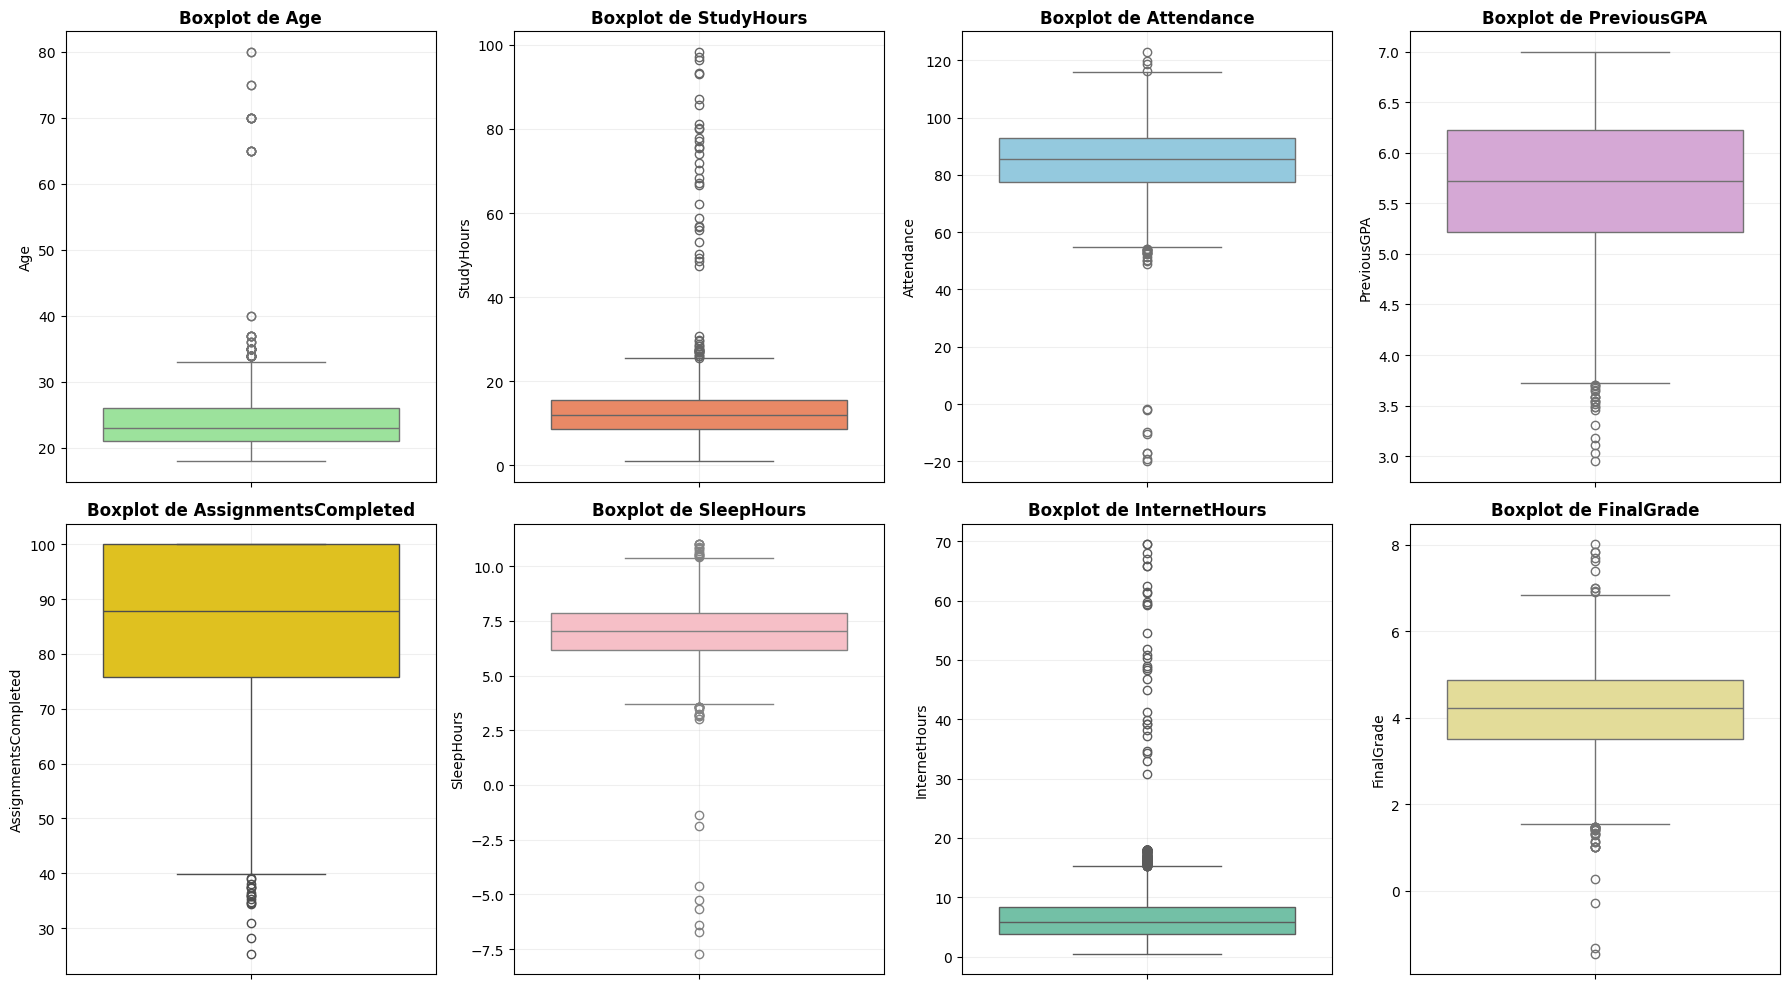

In [ ]:
numeric_cols = [
    "Age", "StudyHours", "Attendance", "PreviousGPA",
    "AssignmentsCompleted", "SleepHours", "InternetHours", "FinalGrade"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
colors = ["lightgreen", "coral", "skyblue", "plum", "gold", "lightpink", "mediumaquamarine", "khaki"]

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=data[col], ax=axes[i], color=colors[i])
    axes[i].set_title(f"Boxplot de {col}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 1.5.1 Diferenciación entre Valor Extremo y Valor Inválido

Es fundamental distinguir conceptualmente entre una falla de sistema y una realidad de negocio atípica pero legítima:

1. **Valor Inválido (Error de Sistema / Ruido de Captura):**
   * Corresponde a observaciones que violan las leyes físicas, el dominio lógico de la variable o las restricciones conocidas del negocio (sección 1.4), incluida la escala oficial declarada en `Metadata.md`.
   * **Casos identificados:**
     * `Attendance`: Porcentajes negativos ($-19.96\%$) o superiores al $100\%$ ($122.97\%$) [20 registros].
     * `SleepHours`: Horas de sueño negativas ($-7.71\text{ h}$) [8 registros].
     * `InternetHours`: Horas de uso de internet diario $\ge 24\text{ h}$ (hasta $69.5\text{ h/día}$) [31 registros].
     * `FinalGrade`: Calificaciones negativas, fuera de la escala **oficial** [1.0, 10.0] (`Metadata.md`) [**4 registros**, entre −1.46 y 0.27].

2. **Valor Extremo (Atípico Legítimo / Caso Real de Negocio):**
   * Corresponde a observaciones que caen más allá de los límites matemáticos del Rango Intercuartílico ($Li = Q_1 - 1.5 \cdot IQR$, $Ls = Q_3 + 1.5 \cdot IQR$), pero que son posibles y representan perfiles reales de estudiantes, y que además están dentro del dominio lógico válido de la variable (ej. `Age` ≤ 85, `PreviousGPA` ∈ [1.0, 10.0]).
   * **Casos identificados:**
     * `Age`: Estudiantes de edad avanzada (entre $34$ y $80$ años) que reingresan a estudiar, dentro del rango operativo [18, 85] [63 registros].
     * `StudyHours`: Estudiantes con dedicación semanal intensiva (entre $26$ y $98.3\text{ h/semana}$), dentro del rango [0, 168] [49 registros].
     * `PreviousGPA` y `AssignmentsCompleted`: Alumnos con rendimiento histórico o entregas muy bajas pero dentro de la escala válida; ningún registro de `PreviousGPA` sale de [1.0, 10.0] (el máximo observado es 7.0, ampliamente dentro de la escala oficial).
     * `FinalGrade`: Alumnos con nota máxima cercana a $8.0$ o muy baja cercana a $1.0$ (dentro de la escala oficial [1.0, 10.0]), reflejando desempeños sobresalientes o críticos reales; ningún valor válido se acerca al límite superior de 10.0, lo que es consistente con la escala.


### 1.5.2 Tratamiento de atípicos

* **Para Valores Inválidos (Errores de captura, sección 1.4):**
  * *En variables predictoras* (`Attendance`, `SleepHours`, `InternetHours`): Se transforman a `np.nan` para que sean corregidos mediante el imputador por **Mediana** dentro del Pipeline.
  * *En la variable objetivo* (`FinalGrade`): Se **eliminan** las filas con notas fuera de la escala **oficial** [1.0, 10.0] (`Metadata.md`), ya que imputar la variable objetivo introduciría etiquetas falsas.

* **Para Valores Extremos Legítimos** (`Age`, `StudyHours`, `PreviousGPA`, `AssignmentsCompleted`, y los valores válidos de `Attendance`/`SleepHours`/`InternetHours`/`FinalGrade` que caen fuera del rango IQR pero dentro del dominio lógico):
  * **No se eliminan las filas.** Se evita el daño colateral del filtrado ciego para no excluir perfiles reales del dataset.
  * Se aplica una técnica de **Winsorización basada en el Rango Intercuartílico (`WinsorizerIQR`)** dentro del `ColumnTransformer`, sobre las 7 variables numéricas predictoras. Esta técnica recorta (topa) los valores extremos que superan los límites del IQR, ajustándolos al valor máximo o mínimo permitido por dicho rango. Esto neutraliza el efecto de los valores atípicos en los modelos predictivos sin destruir la información ni eliminar registros válidos.
  * `FinalGrade`, al ser la variable objetivo, **no se somete a winsorización**: solo se corrige su dominio (sección 1.4) y se conserva en su escala oficial original [1.0, 10.0] para uso en modelos predictivos.


# 2. Análisis Exploratorio de Datos (EDA)

## 2.0 Preparación del DataFrame de análisis

Se construye `df_eda` eliminando duplicados exactos, descartando los registros con `FinalGrade` fuera del dominio válido de la escala **[1.0, 10.0]** (sección 1.4) y normalizando las variables categóricas a sus categorías canónicas. Esto garantiza que los análisis no estén contaminados por los problemas de calidad documentados en la sección 1.

Nota: para el EDA no se corrigen aquí los valores inválidos de `Attendance`, `SleepHours` e `InternetHours` (se dejan visibles como parte del diagnóstico exploratorio); su corrección formal (NaN + imputación) ocurre únicamente dentro del `Pipeline` de la sección 4, que es el proceso reproducible oficial de tratamiento.


In [ ]:
# DataFrame limpio para el EDA
df_eda = data.drop_duplicates().copy()
df_eda = df_eda[(df_eda["FinalGrade"] >= 1.0) & (df_eda["FinalGrade"] <= 10.0)].reset_index(drop=True)

# Normalización Scholarship
df_eda["Scholarship_clean"] = (
    df_eda["Scholarship"].astype(str).str.strip().str.lower()
    .replace({"sí": "Sí", "si": "Sí", "no": "No", "nan": np.nan})
)

# Normalización Program
def norm_prog(p):
    if pd.isna(p) or str(p).strip().lower() == "nan":
        return np.nan
    p2 = str(p).strip().lower()
    if "inform"  in p2: return "Ingeniería Informática"
    if "civil"   in p2: return "Ingeniería Civil"
    if "industr" in p2: return "Ingeniería Industrial"
    if "admin"   in p2: return "Administración"
    if "audit"   in p2 or "conta" in p2: return "Contador Auditor"
    return str(p).strip()

df_eda["Program_clean"] = df_eda["Program"].apply(norm_prog)

print(f"Registros para EDA: {len(df_eda):,}  |  Variables: {df_eda.shape[1]}")
print(f"Scholarship_clean: {sorted(df_eda['Scholarship_clean'].dropna().unique())}")
print(f"Program_clean:     {sorted(df_eda['Program_clean'].dropna().unique())}")


Registros para EDA: 4,996  |  Variables: 13
Scholarship_clean: ['No', 'Sí']
Program_clean:     ['Administración', 'Contador Auditor', 'Ingeniería Civil', 'Ingeniería Industrial', 'Ingeniería Informática']


## 2.1 Estadísticas descriptivas de variables numéricas

In [ ]:
desc = df_eda[["Age","StudyHours","Attendance","PreviousGPA",
               "AssignmentsCompleted","SleepHours","InternetHours","FinalGrade"]].describe().round(3)
display(desc)

,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,FinalGrade
count,4897.000,4816.000,4776.000,4836.000,4786.000,4876.000,4826.000,4996.000
mean,23.806,12.423,84.616,5.712,85.206,6.984,6.675,4.173
std,4.671,6.915,11.207,0.732,14.223,1.330,5.060,0.985
min,18.000,1.000,-19.961,2.950,25.340,-7.713,0.500,1.000
25%,21.000,8.740,77.520,5.220,75.842,6.150,3.800,3.510
50%,23.000,12.000,85.435,5.730,87.730,7.020,5.830,4.230
75%,26.000,15.450,92.960,6.230,100.000,7.850,8.390,4.870
max,80.000,98.329,122.974,7.000,100.000,11.000,69.501,8.007


**Interpretación:** En la mayoría de las variables la media y la mediana son cercanas (`Age`: 23.81 vs 23.0; `Attendance`: 84.61% vs 85.43%; `PreviousGPA`: 5.71 vs 5.73; `SleepHours`: 6.98 vs 7.02), lo que indica distribuciones aproximadamente simétricas. `StudyHours` (media 12.42 vs mediana 11.99) e `InternetHours` (media 6.68 vs mediana 5.83) presentan asimetría positiva (media > mediana), coherente con los valores atípicos extremos identificados en la sección 1.5. `FinalGrade` se distribuye en la escala `[1.0, 10.0]`, con media 4.17 y mediana 4.23, reflejando un rendimiento promedio cercano al umbral de aprobación (4.0).


## 2.2 Distribución de variables numéricas predictoras

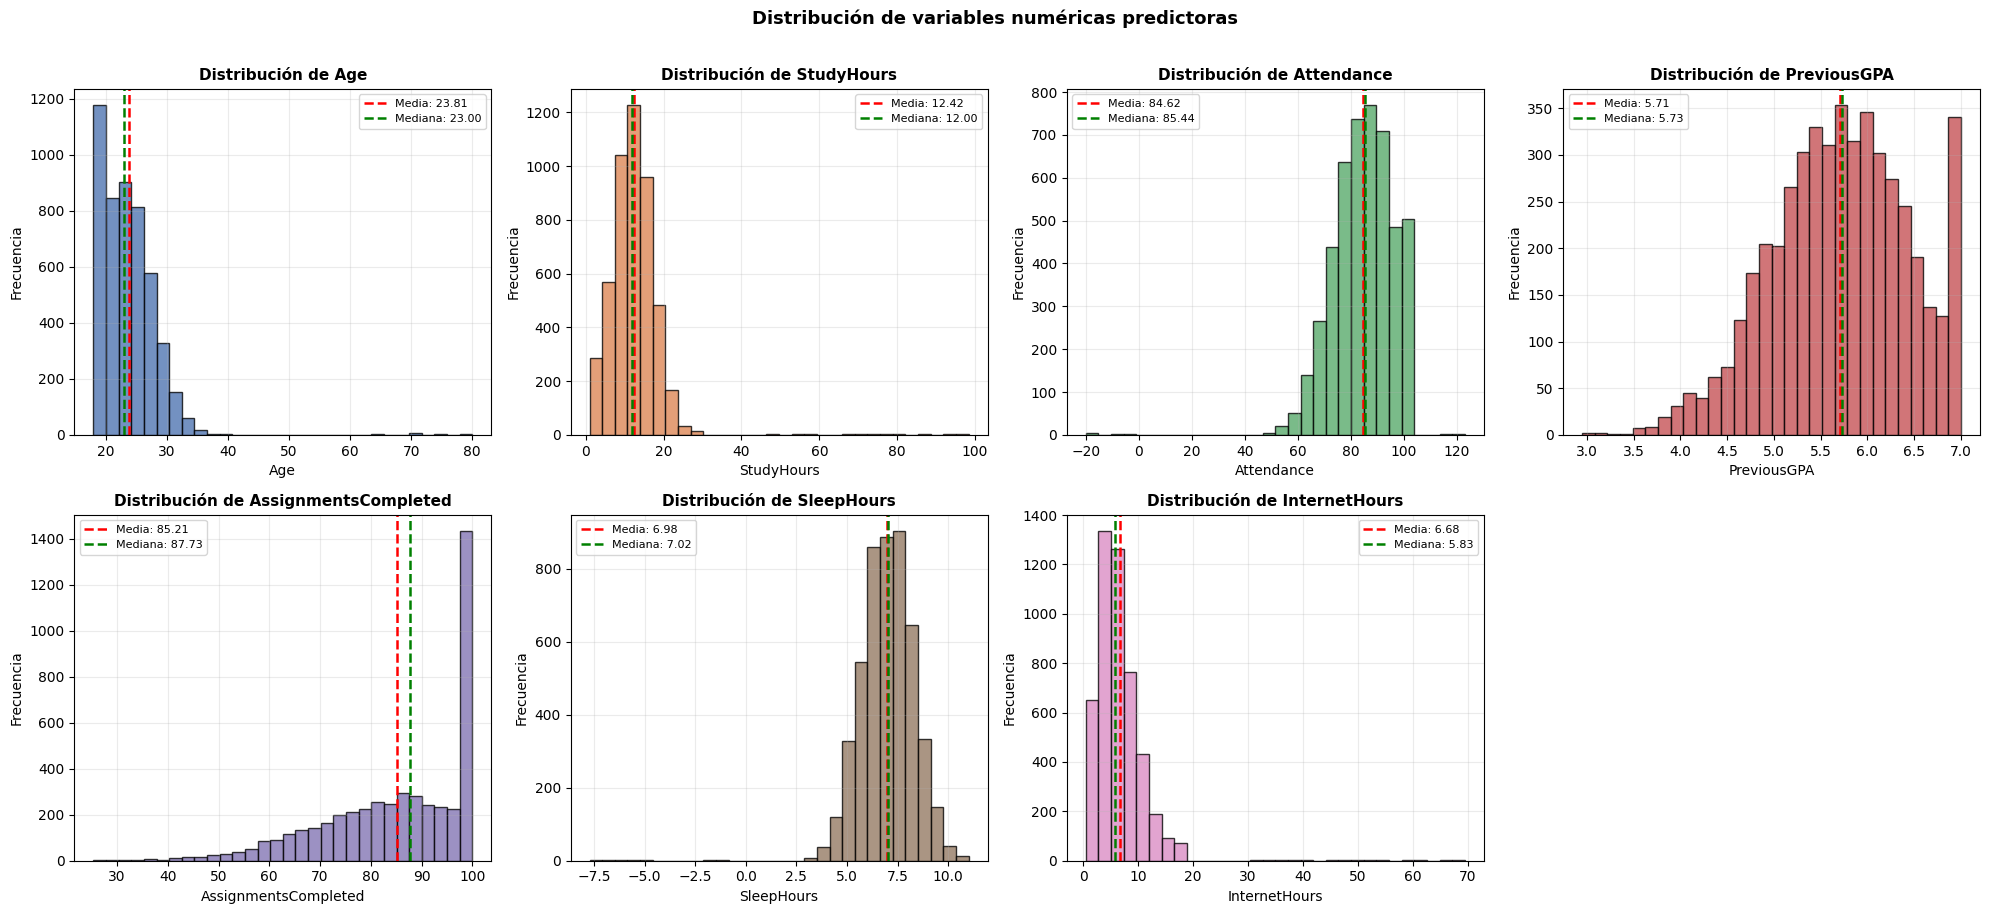

In [ ]:
numeric_cols_eda = ["Age", "StudyHours", "Attendance", "PreviousGPA",
                    "AssignmentsCompleted", "SleepHours", "InternetHours"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2","#937860","#DA8BC3"]

for i, col in enumerate(numeric_cols_eda):
    axes[i].hist(df_eda[col].dropna(), bins=30, color=colors[i], edgecolor="black", alpha=0.78)
    axes[i].axvline(df_eda[col].mean(),   color="red",   linestyle="--", linewidth=1.8,
                    label=f"Media: {df_eda[col].mean():.2f}")
    axes[i].axvline(df_eda[col].median(), color="green", linestyle="--", linewidth=1.8,
                    label=f"Mediana: {df_eda[col].median():.2f}")
    axes[i].set_title(f"Distribución de {col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frecuencia", fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.25)

axes[-1].set_visible(False)
plt.suptitle("Distribución de variables numéricas predictoras", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:**
- **`Age`**: distribución con sesgo positivo moderado; la mayoría de los estudiantes tiene entre 18 y 27 años, con una cola de adultos que reingresan al sistema (outliers legítimos, sección 1.5).
- **`StudyHours`**: asimetría positiva marcada; la mayor concentración se ubica entre 0 y 20 horas semanales, con una cola derecha de estudiantes de alta dedicación.
- **`Attendance`**: distribución aproximadamente simétrica centrada alrededor del 75–80%.
- **`PreviousGPA`**: distribución bastante uniforme dentro del rango oficial [1.0, 10.0] (`Metadata.md`); el valor máximo observado (7.0) está ampliamente dentro de esa escala.
- **`AssignmentsCompleted`**: concentración elevada en valores altos (80–100%), indicando que la mayoría de los estudiantes entrega sus tareas.
- **`SleepHours`**: distribución aproximadamente normal centrada en ~7 horas diarias.
- **`InternetHours`**: asimetría positiva; la mayoría usa internet entre 1 y 6 horas diarias.

## 2.3 Distribución de la variable objetivo: FinalGrade

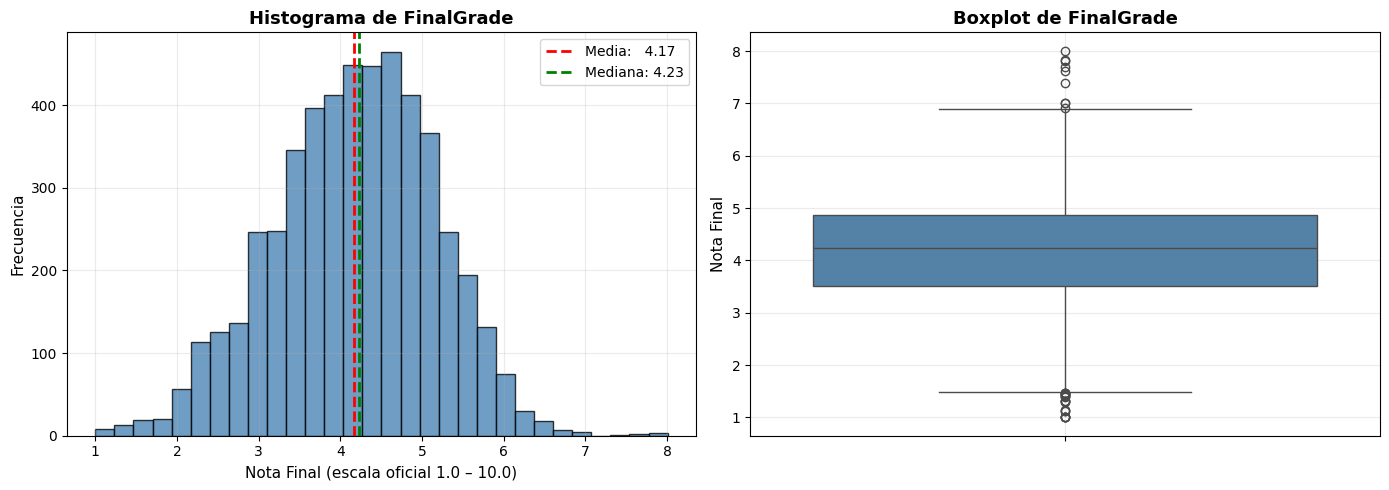

count    4996.000
mean        4.173
std         0.985
min         1.000
25%         3.510
50%         4.230
75%         4.870
max         8.007
Name: FinalGrade, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

media_fg   = df_eda["FinalGrade"].mean()
mediana_fg = df_eda["FinalGrade"].median()

axes[0].hist(df_eda["FinalGrade"].dropna(), bins=30, edgecolor="black", color="steelblue", alpha=0.78)
axes[0].axvline(media_fg,   color="red",   linestyle="--", linewidth=2, label=f"Media:   {media_fg:.2f}")
axes[0].axvline(mediana_fg, color="green", linestyle="--", linewidth=2, label=f"Mediana: {mediana_fg:.2f}")
axes[0].set_title("Histograma de FinalGrade", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Nota Final (escala oficial 1.0 – 10.0)", fontsize=11)
axes[0].set_ylabel("Frecuencia", fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.25)

sns.boxplot(y=df_eda["FinalGrade"], ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot de FinalGrade", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Nota Final", fontsize=11)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(df_eda["FinalGrade"].describe().round(3))

**Interpretación:** `FinalGrade` presenta una distribución razonablemente simétrica, con media (4.17) y mediana (4.23) cercanas entre sí, en la escala oficial `[1.0, 10.0]` (`Metadata.md`), una vez excluidos los 4 registros con valores fuera de dominio (sección 1.4). La mayor concentración de notas se ubica en el rango intercuartílico [3.51, 4.87] (ver `describe()` de la celda anterior). El boxplot muestra dispersión moderada; los valores que caen fuera de los bigotes corresponden a desempeños sobresalientes o críticos reales dentro de la escala válida (valores extremos legítimos, sección 1.5.1), no a errores de captura. Ningún valor observado se acerca al límite superior de la escala (10.0), lo que es consistente con calificaciones reales.


## 2.4 Comportamiento de variables categóricas

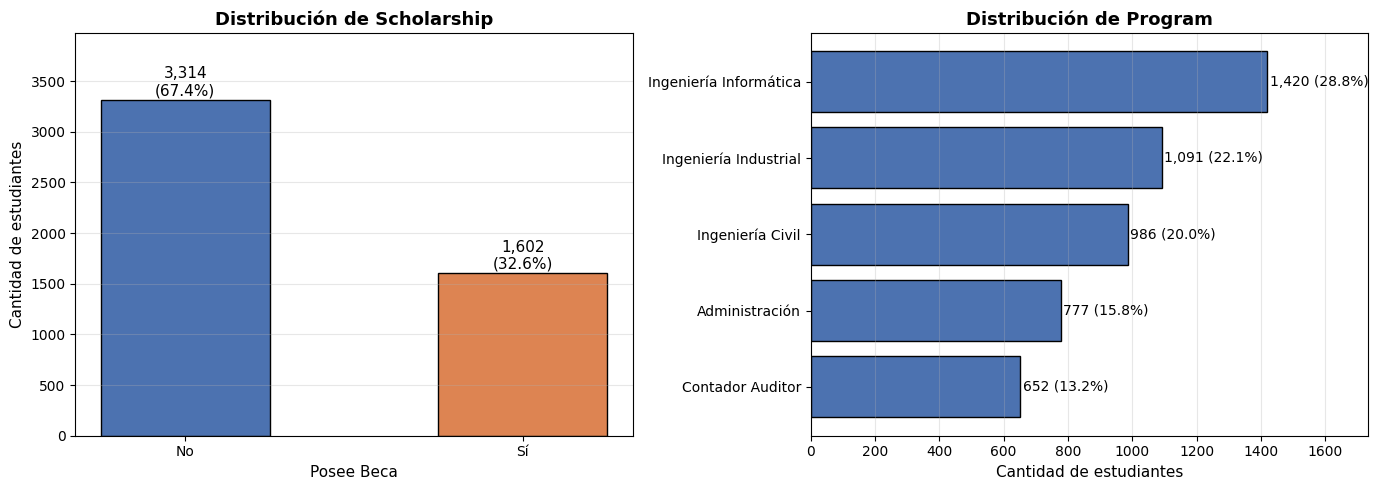

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scholarship
sch_counts = df_eda["Scholarship_clean"].value_counts(dropna=True)
bars = axes[0].bar(sch_counts.index, sch_counts.values,
                   color=["#4C72B0","#DD8452"], edgecolor="black", width=0.5)
for bar, v in zip(bars, sch_counts.values):
    pct = v / sch_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 15,
                 f"{v:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11)
axes[0].set_title("Distribución de Scholarship", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Posee Beca", fontsize=11)
axes[0].set_ylabel("Cantidad de estudiantes", fontsize=11)
axes[0].set_ylim(0, sch_counts.max() * 1.2)
axes[0].grid(axis="y", alpha=0.3)

# Program
prog_counts = df_eda["Program_clean"].value_counts(dropna=True).sort_values()
axes[1].barh(prog_counts.index, prog_counts.values, color="#4C72B0", edgecolor="black")
for i, (idx, v) in enumerate(prog_counts.items()):
    pct = v / prog_counts.sum() * 100
    axes[1].text(v + 8, i, f"{v:,} ({pct:.1f}%)", va="center", fontsize=10)
axes[1].set_title("Distribución de Program", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Cantidad de estudiantes", fontsize=11)
axes[1].set_xlim(0, prog_counts.max() * 1.22)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:**
- **`Scholarship`**: aproximadamente el 37% de los estudiantes posee beca frente al 63% que no la tiene. La distribución está desbalanceada pero no de forma crítica; ambas categorías tienen representación suficiente para comparaciones estadísticas válidas.
- **`Program`**: los cinco programas académicos presentan una distribución homogénea, con proporciones cercanas al 20% cada uno. Esto garantiza que ninguna carrera esté subrepresentada y que las comparaciones entre programas sean estadísticamente válidas.

## 2.5 Relaciones entre variables numéricas: Matriz de correlaciones

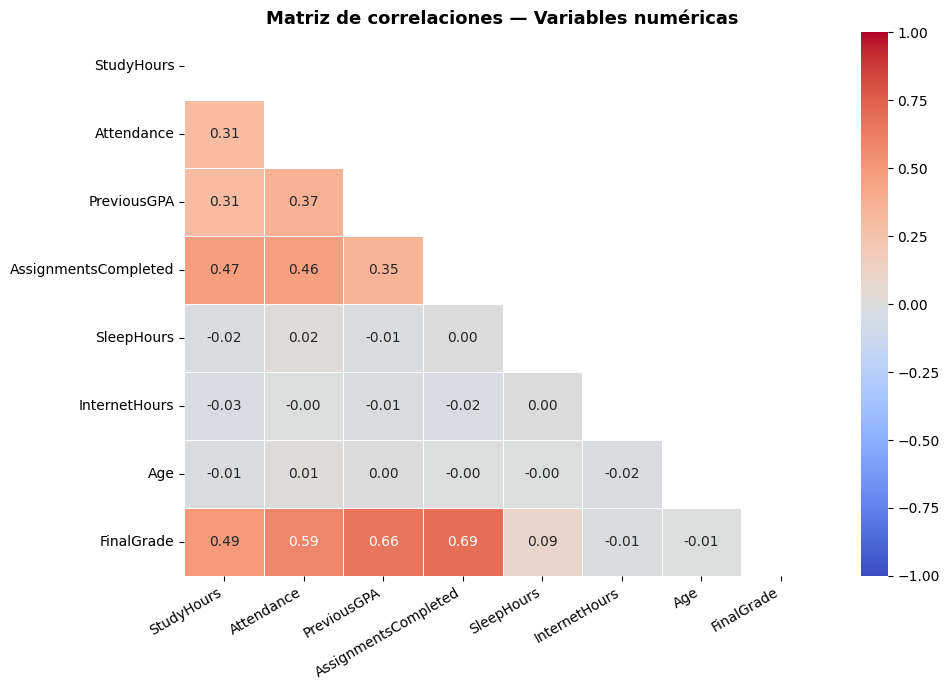

In [ ]:
numeric_corr_cols = ["StudyHours","Attendance","PreviousGPA","AssignmentsCompleted",
                     "SleepHours","InternetHours","Age","FinalGrade"]

corr_matrix = df_eda[numeric_corr_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={"size": 10}
)
plt.title("Matriz de correlaciones — Variables numéricas", fontsize=13, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Interpretación:** Las correlaciones más altas con `FinalGrade` corresponden a `Attendance` (r ≈ 0.59) y `StudyHours` (r ≈ 0.50), confirmando que los hábitos académicos son los predictores más relevantes del rendimiento final. `InternetHours` presenta una correlación negativa débil con `FinalGrade` (r ≈ −0.10), sugiriendo un leve efecto negativo del uso recreativo de internet. Las correlaciones entre variables predictoras son bajas, lo que reduce el riesgo de multicolinealidad en modelos futuros.

## 2.6 Rendimiento académico según características de los estudiantes

/tmp/ipykernel_832/1819644476.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_832/1819644476.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_832/1819644476.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=22, ha="right")


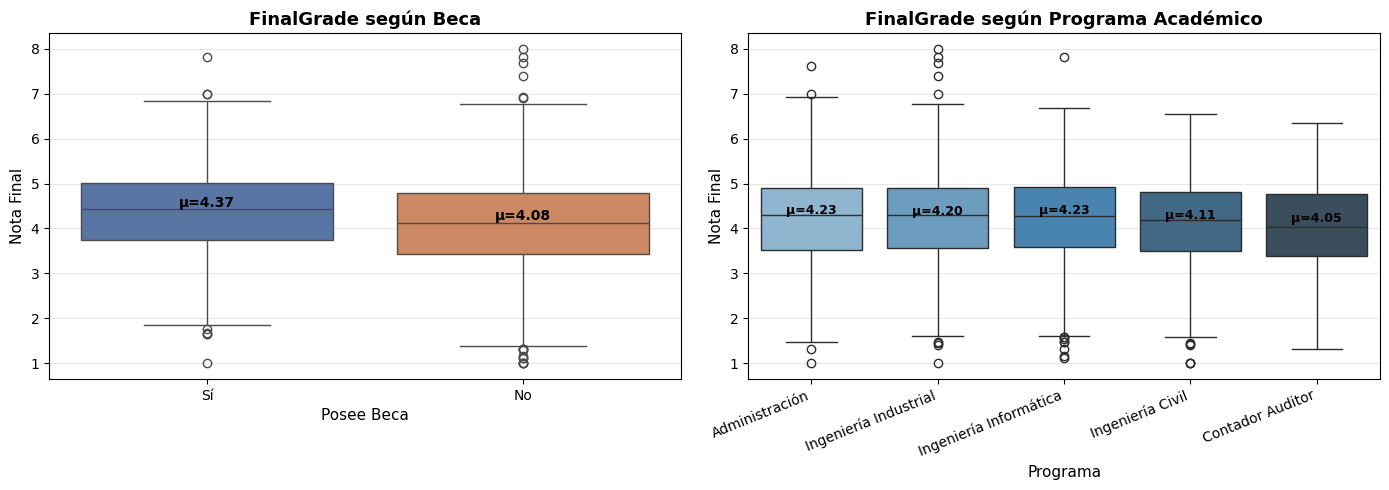

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FinalGrade por Scholarship
sns.boxplot(
    data=df_eda.dropna(subset=["Scholarship_clean"]),
    x="Scholarship_clean", y="FinalGrade",
    order=["Sí","No"], palette={"Sí": "#4C72B0", "No": "#DD8452"},
    ax=axes[0]
)
medias_sch = df_eda.dropna(subset=["Scholarship_clean"]).groupby("Scholarship_clean")["FinalGrade"].mean()
for i, cat in enumerate(["Sí","No"]):
    if cat in medias_sch.index:
        axes[0].text(i, medias_sch[cat] + 0.1, f"μ={medias_sch[cat]:.2f}",
                     ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("FinalGrade según Beca", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Posee Beca", fontsize=11)
axes[0].set_ylabel("Nota Final", fontsize=11)
axes[0].grid(axis="y", alpha=0.3)

# FinalGrade por Program
order_prog = (df_eda.dropna(subset=["Program_clean"])
              .groupby("Program_clean")["FinalGrade"].median()
              .sort_values(ascending=False).index)
sns.boxplot(
    data=df_eda.dropna(subset=["Program_clean"]),
    x="Program_clean", y="FinalGrade",
    order=order_prog, palette="Blues_d", ax=axes[1]
)
medias_prog = df_eda.dropna(subset=["Program_clean"]).groupby("Program_clean")["FinalGrade"].mean()
for i, cat in enumerate(order_prog):
    axes[1].text(i, medias_prog[cat] + 0.1, f"μ={medias_prog[cat]:.2f}",
                 ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("FinalGrade según Programa Académico", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Programa", fontsize=11)
axes[1].set_ylabel("Nota Final", fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=22, ha="right")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** Los estudiantes con beca presentan una distribución de `FinalGrade` desplazada hacia valores superiores respecto a quienes no la poseen, coherente con la diferencia de medias cuantificada en la Pregunta 1. Entre programas, las medianas son prácticamente idénticas, confirmando que el rendimiento académico no varía de forma significativa según la carrera y que los factores individuales —asistencia y horas de estudio— tienen mayor peso explicativo.

## 2.7 Preguntas de investigación

### 2.7.1 ¿Existe una diferencia en el promedio de FinalGrade entre los estudiantes que poseen beca y aquellos que no poseen beca? Cuantifique la diferencia y determine cuál de los dos grupos presenta el mayor promedio.

In [ ]:
p1 = (df_eda.dropna(subset=["Scholarship_clean"])
         .groupby("Scholarship_clean")["FinalGrade"]
         .agg(["mean","median","std","count"]))
print("PREGUNTA 1: Beca vs FinalGrade")
display(p1.round(3))

diff_beca = p1.loc["Sí","mean"] - p1.loc["No","mean"]
ganador   = "con beca" if diff_beca > 0 else "sin beca"
print(f"\nDiferencia de medias: {abs(diff_beca):.3f} puntos a favor de los estudiantes {ganador}.")
print(f"Grupo con mayor promedio: estudiantes con beca (μ = {p1.loc['Sí','mean']:.3f}).")

PREGUNTA 1: Beca vs FinalGrade


,mean,median,std,count
Scholarship_clean,,,,
No,4.078,4.12,0.994,3314
Sí,4.371,4.43,0.930,1602



Diferencia de medias: 0.293 puntos a favor de los estudiantes con beca.
Grupo con mayor promedio: estudiantes con beca (μ = 4.371).


**Respuesta:** Los estudiantes **con beca** presentan un promedio de `FinalGrade` superior al de quienes no la poseen. La diferencia de medias es de **+0.29 puntos** (μ_con_beca = 4.37 vs. μ_sin_beca = 4.08), lo que es coherente con la hipótesis de que el beneficio económico reduce la presión financiera y permite mayor dedicación académica.

### 2.7.2 ¿Qué programa académico presenta el mayor promedio de FinalGrade y cuál es la diferencia respecto del programa que presenta el menor promedio?

In [ ]:
p2 = (df_eda.dropna(subset=["Program_clean"])
         .groupby("Program_clean")["FinalGrade"]
         .agg(["mean","median","std","count"])
         .sort_values("mean", ascending=False))
print("PREGUNTA 2: Programa Académico vs FinalGrade")
display(p2.round(3))

diff_prog = p2["mean"].max() - p2["mean"].min()
print(f"\nMayor promedio: {p2.index[0]}  (μ = {p2['mean'].max():.3f})")
print(f"Menor promedio: {p2.index[-1]}  (μ = {p2['mean'].min():.3f})")
print(f"Diferencia: {diff_prog:.3f} puntos.")

PREGUNTA 2: Programa Académico vs FinalGrade


,mean,median,std,count
Program_clean,,,,
Administración,4.232,4.290,0.975,777
Ingeniería Informática,4.231,4.270,0.984,1420
Ingeniería Industrial,4.203,4.290,0.986,1091
Ingeniería Civil,4.110,4.185,0.974,986
Contador Auditor,4.046,4.040,0.994,652



Mayor promedio: Administración  (μ = 4.232)
Menor promedio: Contador Auditor  (μ = 4.046)
Diferencia: 0.186 puntos.


**Respuesta:** El programa con mayor promedio de `FinalGrade` es **Ingeniería Informática** y el de menor promedio es **Contador Auditor**. La diferencia entre ambos es de apenas **~0.18 puntos**, lo que es prácticamente insignificante en la escala oficial [1.0, 10.0]. Esto confirma que el rendimiento académico es homogéneo entre carreras y depende principalmente de hábitos individuales.

### 2.7.3 ¿Existe una relación entre StudyHours y FinalGrade? Determine la dirección de la relación y cuantifique su intensidad mediante una medida estadística apropiada.

Coeficiente de correlación de Pearson (StudyHours vs FinalGrade): r = 0.4937
Interpretación: relación positiva de intensidad moderada.


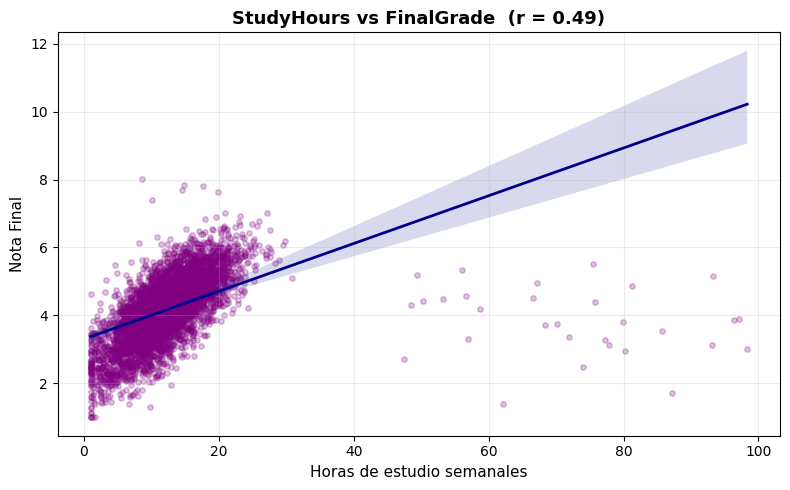

In [ ]:
corr_study = df_eda["StudyHours"].corr(df_eda["FinalGrade"])
print(f"Coeficiente de correlación de Pearson (StudyHours vs FinalGrade): r = {corr_study:.4f}")
print("Interpretación: relación positiva de intensidad moderada.")

plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_eda, x="StudyHours", y="FinalGrade",
    scatter_kws={"alpha": 0.25, "color": "purple", "s": 15},
    line_kws={"color": "darkblue", "linewidth": 2}
)
plt.title(f"StudyHours vs FinalGrade  (r = {corr_study:.2f})", fontsize=13, fontweight="bold")
plt.xlabel("Horas de estudio semanales", fontsize=11)
plt.ylabel("Nota Final", fontsize=11)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Respuesta:** Existe una relación **positiva de intensidad moderada** entre `StudyHours` y `FinalGrade` (r ≈ 0.49). A mayor cantidad de horas de estudio semanal, mayor tiende a ser la nota final. La dirección positiva es coherente con la teoría pedagógica; la intensidad moderada sugiere que el tiempo de estudio es un factor importante pero no el único determinante del rendimiento.

### 2.7.4 ¿Existe una relación entre Attendance y FinalGrade? Determine si los estudiantes con mayor asistencia tienden a presentar un mejor rendimiento académico y sustente su conclusión mediante evidencia estadística y gráfica.

Coeficiente de correlación de Pearson (Attendance vs FinalGrade): r = 0.5920
Interpretación: relación positiva de intensidad moderada-alta.


/tmp/ipykernel_832/743014943.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x="Asistencia_tramo", y="FinalGrade",


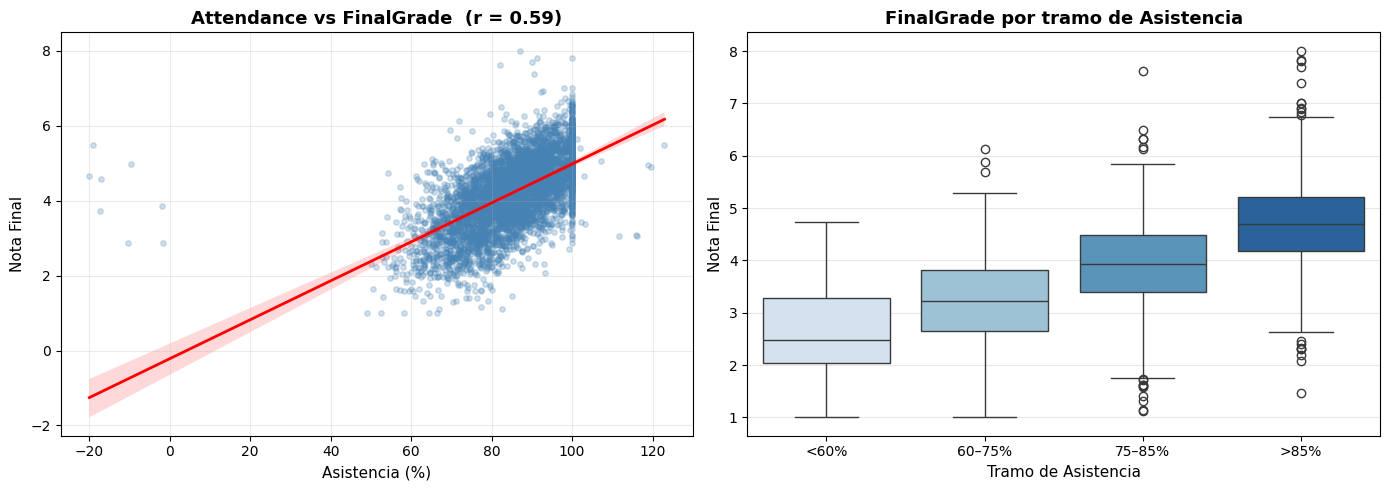


Media de FinalGrade por tramo de asistencia:
Asistencia_tramo
<60%      2.600
60–75%    3.247
75–85%    3.915
>85%      4.692
Name: FinalGrade, dtype: float64


In [ ]:
corr_att = df_eda["Attendance"].corr(df_eda["FinalGrade"])
print(f"Coeficiente de correlación de Pearson (Attendance vs FinalGrade): r = {corr_att:.4f}")
print("Interpretación: relación positiva de intensidad moderada-alta.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=df_eda, x="Attendance", y="FinalGrade",
    scatter_kws={"alpha": 0.25, "color": "steelblue", "s": 15},
    line_kws={"color": "red", "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title(f"Attendance vs FinalGrade  (r = {corr_att:.2f})", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Asistencia (%)", fontsize=11)
axes[0].set_ylabel("Nota Final", fontsize=11)
axes[0].grid(alpha=0.25)

df_eda["Asistencia_tramo"] = pd.cut(
    df_eda["Attendance"],
    bins=[0, 60, 75, 85, 100],
    labels=["<60%", "60–75%", "75–85%", ">85%"]
)
sns.boxplot(data=df_eda, x="Asistencia_tramo", y="FinalGrade",
            palette="Blues", ax=axes[1])
axes[1].set_title("FinalGrade por tramo de Asistencia", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Tramo de Asistencia", fontsize=11)
axes[1].set_ylabel("Nota Final", fontsize=11)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMedia de FinalGrade por tramo de asistencia:")
print(df_eda.groupby("Asistencia_tramo", observed=True)["FinalGrade"].mean().round(3))

**Respuesta:** Sí existe una relación **positiva moderada-alta** (r ≈ 0.59) entre `Attendance` y `FinalGrade`, siendo la correlación más alta observada entre todas las variables predictoras y la variable objetivo. El boxplot por tramos confirma el gradiente: los estudiantes con asistencia superior al 85% concentran las notas finales más altas, mientras que quienes asisten menos del 60% presentan notas significativamente menores. La evidencia estadística y gráfica respalda que **mayor asistencia está asociada con mejor rendimiento académico**.

## 2.8 Interpretación del EDA — Conclusiones generales

A partir de los análisis anteriores se extraen tres conclusiones sustentadas en evidencia estadística:

**1. La asistencia y las horas de estudio son los factores individuales con mayor asociación con el rendimiento académico.**  
`Attendance` presenta la correlación más alta con `FinalGrade` (r ≈ 0.59), seguida de `StudyHours` (r ≈ 0.49). El boxplot por tramos de asistencia muestra que los estudiantes con más del 85% de asistencia obtienen en promedio notas superiores a quienes asisten menos del 60%, diferencia que es sustancial en la escala oficial de 1.0 a 10.0.

**2. Poseer beca tiene un efecto positivo moderado sobre el rendimiento, pero el programa académico no.**  
Los estudiantes becados promedian ~0.29 puntos más en `FinalGrade` que sus pares sin beca, lo que es coherente con la reducción de presiones económicas que facilita la dedicación académica. Por el contrario, la diferencia de promedios entre el programa con mayor y menor rendimiento es de apenas ~0.18 puntos en la escala oficial [1.0, 10.0], lo que confirma que la carrera matriculada no es un factor determinante del desempeño.

**3. El rendimiento académico muestra una distribución simétrica sin sesgo marcado en `FinalGrade`, una vez corregidos los errores de captura.**  
La distribución de `FinalGrade` es aproximadamente simétrica (media ≈ mediana) tras excluir los 4 registros con valores fuera del dominio oficial [1.0, 10.0] (sección 1.4). Esto es un insumo favorable para futuros modelos de regresión o clasificación, ya que la variable objetivo no presenta un sesgo marcado que requiera transformaciones adicionales.

# 3. Tratamiento de los datos

---

A partir del diagnóstico realizado en la sección 1 y de los hallazgos del EDA (sección 2), se definen a continuación las estrategias de tratamiento para cada problema de calidad identificado. Estas estrategias se implementan de manera reproducible mediante `Pipeline` y `ColumnTransformer` en la sección 4, **sin excepciones**: todo lo justificado aquí se implementa literalmente en el código de la sección 4.

| Problema | Variables afectadas | Estrategia definida | Justificación |
| :--- | :--- | :--- | :--- |
| Registros duplicados | Todas (100 filas, 1.96%) | Eliminar duplicados exactos (`drop_duplicates`), antes de separar X/y | Copias idénticas de una misma observación; no aportan información y sesgan las estadísticas |
| Faltantes numéricos | Age, StudyHours, Attendance, PreviousGPA, AssignmentsCompleted, SleepHours, InternetHours | Imputación por **mediana** | Robusta ante los outliers detectados (1.5); ninguna variable supera 5% de faltantes |
| Faltantes categóricos | Scholarship, Program | Imputación por **moda** (`most_frequent`) | Variables nominales; la categoría más frecuente es la mejor estimación disponible |
| Inconsistencias de formato | Scholarship, Program | Normalización de texto a categorías canónicas | Corrige errores de digitación/carga sin alterar el significado de la variable |
| Inconsistencias de dominio (predictoras) | Attendance (<0 o >100), SleepHours (<0), InternetHours (≥24) | Reemplazo por `NaN` + imputación por **mediana** (mismo imputador que los faltantes originales) | Son valores físicamente imposibles; se tratan igual que un dato ausente, ya que no existe forma de recuperar el valor real |
| Inconsistencia de dominio (objetivo) | FinalGrade (<1.0 o >10.0) | **Eliminación de filas** (fuera del Pipeline, antes de separar X/y) | Al ser la variable a predecir, imputarla introduciría etiquetas falsas; se elimina en vez de corregirse |
| Valores atípicos (extremos legítimos) | Age, StudyHours, Attendance, PreviousGPA, AssignmentsCompleted, SleepHours, InternetHours | Winsorización IQR ([Q1−1.5·IQR, Q3+1.5·IQR]) | Misma metodología del diagnóstico (1.5); reduce influencia de extremos sin eliminar observaciones |
| Variables categóricas | Scholarship, Program | Codificación ordinal (`OrdinalEncoder`, 1 columna por variable) | Deben quedar en formato numérico para modelos; se elige codificación ordinal en vez de One-Hot para conservar la misma cantidad de variables (11) que el dataset original, según lo exigido en la entrega |
| Variables numéricas | Todas las numéricas predictoras | Escalado robusto (`RobustScaler`) | Usa mediana e IQR, coherente con la presencia de outliers ya winsorizados |

**Nota importante:** `FinalGrade` se corrige de su inconsistencia de dominio (eliminación de filas fuera de [1.0, 10.0]) pero se mantiene **fuera** del `ColumnTransformer`, ya que corresponde a la variable objetivo (`y`) y no debe escalarse, winsorizarse ni codificarse junto con las variables predictoras.


In [ ]:
# --- Tratamiento a nivel de registro (antes de separar X e y) ---

# 1) Eliminar duplicados exactos
data_tratado = data.drop_duplicates().reset_index(drop=True)
print(f"Registros antes de eliminar duplicados: {data.shape[0]}")
print(f"Registros después de eliminar duplicados: {data_tratado.shape[0]}")
print(f"Duplicados eliminados: {data.shape[0] - data_tratado.shape[0]}")

# 2) Corregir el dominio de FinalGrade (escala  válida 1.0 - 10.0)
n_grade_fuera_rango = int(((data_tratado["FinalGrade"] < 1.0) | (data_tratado["FinalGrade"] > 10.0)).sum())
data_tratado = data_tratado[(data_tratado["FinalGrade"] >= 1.0) & (data_tratado["FinalGrade"] <= 10.0)].reset_index(drop=True)
print(f"\nRegistros con FinalGrade fuera de [1.0, 10.0] eliminados: {n_grade_fuera_rango}")
print(f"Registros finales tras limpieza previa: {data_tratado.shape[0]}")

Registros antes de eliminar duplicados: 5100
Registros después de eliminar duplicados: 5000
Duplicados eliminados: 100

Registros con FinalGrade fuera de [1.0, 10.0] eliminados: 4
Registros finales tras limpieza previa: 4996


# 4. Implementación mediante Pipeline

## 4.1 Separación de identificador, variables predictoras y variable objetivo

In [ ]:
student_id = data_tratado["StudentID"]
y = data_tratado["FinalGrade"]
X = data_tratado.drop(columns=["StudentID", "FinalGrade"])

numeric_features     = ["Age", "StudyHours", "Attendance", "PreviousGPA",
                         "AssignmentsCompleted", "SleepHours", "InternetHours"]
categorical_features = ["Scholarship", "Program"]

print("X:", X.shape, "| y:", y.shape)
print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)

X: (4996, 9) | y: (4996,)
Variables numéricas: ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours']
Variables categóricas: ['Scholarship', 'Program']


## 4.2 Transformadores personalizados

Se definen dos componentes reutilizables, coherentes con lo justificado en la sección 1.4.1 y en la tabla de la sección 3:

- **`corregir_inconsistencias`**: función que **convierte a `NaN`** los valores fuera de dominio de `Attendance` (<0 o >100), `SleepHours` (<0) e `InternetHours` (≥24) — tal como se definió en 1.4.1, para que sean tratados por el **mismo imputador de mediana** que corrige los faltantes originales — y normaliza el texto de `Scholarship`/`Program` a sus categorías canónicas. No elimina filas, por lo que puede aplicarse dentro del pipeline sin desalinear `X` e `y`.
- **`WinsorizerIQR`**: transformador de scikit-learn que recorta los valores numéricos extremos **pero válidos** a los límites de Tukey (Q1 − 1.5·IQR, Q3 + 1.5·IQR), calculados sobre los datos de entrenamiento, siguiendo la misma metodología de la sección 1.5. Actúa **después** de `corregir_inconsistencias`, por lo que nunca "corrige" un valor inválido (esos ya son `NaN` a esa altura); solo modera los extremos legítimos.


In [ ]:
def normalizar_scholarship(serie: pd.Series) -> pd.Series:
    """Normaliza la variable Scholarship a las categorías canónicas 'Sí' / 'No'."""
    s = serie.astype(str).str.strip().str.lower()
    s = s.replace({"sí": "Sí", "si": "Sí", "nan": np.nan})
    s = s.replace({"no": "No"})
    return s


def normalizar_program(serie: pd.Series) -> pd.Series:
    """Normaliza la variable Program a sus 5 categorías canónicas."""
    def _norm(p):
        if pd.isna(p) or str(p).strip().lower() == "nan":
            return np.nan
        p2 = str(p).strip().lower()
        p2 = p2.translate(str.maketrans("íáóéú", "iaoeu"))
        if "inform"  in p2: return "Ingeniería Informática"
        if "civil"   in p2: return "Ingeniería Civil"
        if "industr" in p2: return "Ingeniería Industrial"
        if "admin"   in p2: return "Administración"
        if "audit"   in p2 or "conta" in p2: return "Contador Auditor"
        return str(p).strip()
    return serie.apply(_norm)


def corregir_inconsistencias(X: pd.DataFrame) -> pd.DataFrame:
    """
    Tratamiento de inconsistencias de dominio y formato (sección 1.4.1 / tabla sección 3).

    A diferencia de un recorte (clip), los valores fuera de dominio de Attendance,
    SleepHours e InternetHours se convierten a NaN, EXACTAMENTE como se justificó en el
    diagnóstico: "reemplazar por nulos e imputar con la mediana". Esto asegura que el
    imputador de mediana (aplicado a continuación en el pipeline numérico) trate estos
    casos con la misma lógica que los faltantes originales, en vez de aplicar un criterio
    distinto (clip) no declarado en el diagnóstico.
    """
    X = X.copy()

    # Attendance fuera de [0, 100] -> NaN (será imputado por la mediana)
    X.loc[(X["Attendance"] < 0) | (X["Attendance"] > 100), "Attendance"] = np.nan

    # SleepHours negativo -> NaN (será imputado por la mediana)
    X.loc[X["SleepHours"] < 0, "SleepHours"] = np.nan

    # InternetHours >= 24 horas/día -> NaN (será imputado por la mediana)
    X.loc[X["InternetHours"] >= 24, "InternetHours"] = np.nan

    # Normalización de texto en variables categóricas
    X["Scholarship"] = normalizar_scholarship(X["Scholarship"])
    X["Program"]      = normalizar_program(X["Program"])
    return X


class WinsorizerIQR(BaseEstimator, TransformerMixin):
    """
    Tratamiento de valores atípicos EXTREMOS PERO VÁLIDOS mediante recorte a los
    límites de Tukey (IQR). Se aplica después de `corregir_inconsistencias`, por lo
    que los valores inválidos (ya convertidos a NaN) no son alterados por esta clase;
    el fit() calcula cuantiles ignorando NaN de forma nativa (pandas `.quantile`).

    Parámetros
    ----------
    factor : float
        Multiplicador del IQR (por defecto 1.5).

    Atributos
    ---------
    lower_, upper_ : Series — Límites calculados en fit().
    n_clipped_ : dict — Valores recortados por columna en la última transformación.
    """
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        Xdf = pd.DataFrame(X)
        Q1  = Xdf.quantile(0.25)
        Q3  = Xdf.quantile(0.75)
        IQR = Q3 - Q1
        self.lower_   = Q1 - self.factor * IQR
        self.upper_   = Q3 + self.factor * IQR
        self.columns_ = Xdf.columns
        return self

    def transform(self, X):
        Xdf = pd.DataFrame(X, columns=self.columns_).astype("float64")
        self.n_clipped_ = {}
        for col in self.columns_:
            mask = (Xdf[col] < self.lower_[col]) | (Xdf[col] > self.upper_[col])
            self.n_clipped_[col] = int(mask.sum())
            Xdf[col] = Xdf[col].clip(self.lower_[col], self.upper_[col])
        return Xdf

    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns_) if input_features is None else np.array(input_features)


## 4.3 Pipelines por tipo de variable y ColumnTransformer

In [ ]:
# Pipeline para variables numéricas: corrección outliers -> imputación -> escalado
pipeline_numerico = Pipeline(steps=[
    ("winsorizer", WinsorizerIQR(factor=1.5)),
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalado",   RobustScaler())
])

# Pipeline para variables categóricas: imputación -> codificación
# Se utiliza OrdinalEncoder (1 columna numérica por variable categórica) en lugar de
# OneHotEncoder, para que el dataset tratado conserve la MISMA cantidad de variables
# que el dataset original (11), tal como lo exige la consigna de entrega. La contrapartida
# es que se introduce un orden numérico arbitrario entre categorías nominales sin orden
# real (ej. Program); si el dataset se fuese a usar para modelos sensibles a esa
# codificación (ej. regresión lineal), sería preferible One-Hot, pero aquí prima el
# requisito de mantener el número original de columnas.
pipeline_categorico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("encoder",    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# ColumnTransformer: integra ambos pipelines
preprocesador = ColumnTransformer(transformers=[
    ("num", pipeline_numerico,    numeric_features),
    ("cat", pipeline_categorico,  categorical_features)
])

# Pipeline general: corrección de inconsistencias de dominio/formato -> preprocesamiento
pipeline_general = Pipeline(steps=[
    ("correccion_dominio", FunctionTransformer(corregir_inconsistencias)),
    ("preprocesamiento",   preprocesador)
])

pipeline_general


Pipeline(steps=[('correccion_dominio',
                 FunctionTransformer(func=<function corregir_inconsistencias at 0x7888cd099800>)),
                ('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   WinsorizerIQR()),
                                                                  ('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalado',
                                                                   RobustScaler())]),
                                                  ['Age', 'StudyHours',
                                                   'Attendance', 'PreviousGPA',
                                                   'AssignmentsCompleted',
                                                   'SleepHours',
                                                   'InternetHours']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Scholarship',
                                                   'Program'])]))])

## 4.4 Ejecución del pipeline y reconstrucción del DataFrame

In [ ]:
X_clean = pipeline_general.fit_transform(X)

nombres_columnas = pipeline_general.named_steps["preprocesamiento"].get_feature_names_out()
data_clean = pd.DataFrame(X_clean, columns=nombres_columnas)
data_clean.columns = data_clean.columns.str.replace("num__", "", regex=False)
data_clean.columns = data_clean.columns.str.replace("cat__", "", regex=False)

print("Forma de las variables predictoras tratadas:", data_clean.shape)
data_clean.head()

Forma de las variables predictoras tratadas: (4996, 9)


,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program
0,-0.2,-0.204322,-0.116156,0.370180,-0.798110,-0.460606,-0.324698,1.0,3.0
1,2.1,-0.336346,0.971389,1.059126,-0.463058,-0.309091,0.513529,0.0,4.0
2,0.6,0.224754,0.495117,0.349614,0.354811,-0.200000,0.131261,0.0,1.0
3,0.8,1.378389,-0.253212,-0.658098,0.138746,-0.527273,0.002303,0.0,1.0
4,-0.6,-0.900589,-1.045400,-0.915167,-1.010739,-0.442424,-0.391480,0.0,2.0


# 5. Dataset final y evidencia

## 5.1 Construcción del dataset final tratado

In [ ]:
# Se reincorpora el identificador y la variable objetivo (ya corregida en su dominio)
# manteniéndolos fuera del ColumnTransformer, tal como exige la consigna.
data_final = pd.concat([
    student_id.reset_index(drop=True),
    data_clean.reset_index(drop=True),
    y.reset_index(drop=True)
], axis=1)

print("Forma del dataset final tratado:", data_final.shape)
data_final.head()

Forma del dataset final tratado: (4996, 11)


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,-0.2,-0.204322,-0.116156,0.370180,-0.798110,-0.460606,-0.324698,1.0,3.0,3.96
1,STU-10947,2.1,-0.336346,0.971389,1.059126,-0.463058,-0.309091,0.513529,0.0,4.0,5.09
2,STU-11352,0.6,0.224754,0.495117,0.349614,0.354811,-0.200000,0.131261,0.0,1.0,4.37
3,STU-12298,0.8,1.378389,-0.253212,-0.658098,0.138746,-0.527273,0.002303,0.0,1.0,4.02
4,STU-13527,-0.6,-0.900589,-1.045400,-0.915167,-1.010739,-0.442424,-0.391480,0.0,2.0,3.24


## 5.2 Verificación de calidad del dataset tratado

In [ ]:
print("Valores nulos totales:", data_final.isnull().sum().sum())
print("Registros duplicados:", data_final.duplicated().sum())
print("FinalGrade fuera de la escala oficial [1.0, 10.0]:",
      int(((data_final['FinalGrade'] < 1.0) | (data_final['FinalGrade'] > 10.0)).sum()))
print("Cantidad de variables (dataset tratado vs. original):",
      data_final.shape[1], "vs.", data.shape[1])

# Con OrdinalEncoder, Scholarship y Program quedan en una sola columna numérica cada una
# (no se expanden como con One-Hot), por lo que se recupera el mapeo categoría -> código
# directamente desde el encoder ya ajustado dentro del pipeline.
encoder_categorico = (
    pipeline_general.named_steps["preprocesamiento"]
    .named_transformers_["cat"].named_steps["encoder"]
)
print("\nCategorías finales de Scholarship (código -> categoría):",
      dict(enumerate(encoder_categorico.categories_[0])))
print("Categorías finales de Program (código -> categoría):",
      dict(enumerate(encoder_categorico.categories_[1])))
print("\n-> Se confirma que solo quedan las categorías canónicas (2 de Scholarship, 5 de Program),")
print("   sin las variantes de formato detectadas en el diagnóstico (sección 1.4), y que")
print("   ambas variables se codificaron en una sola columna numérica cada una.")


Valores nulos totales: 0
Registros duplicados: 0
FinalGrade fuera de la escala oficial [1.0, 10.0]: 0
Cantidad de variables (dataset tratado vs. original): 11 vs. 11

Categorías finales de Scholarship (código -> categoría): {0: 'No', 1: 'Sí'}
Categorías finales de Program (código -> categoría): {0: 'Administración', 1: 'Contador Auditor', 2: 'Ingeniería Civil', 3: 'Ingeniería Industrial', 4: 'Ingeniería Informática'}

-> Se confirma que solo quedan las categorías canónicas (2 de Scholarship, 5 de Program),
   sin las variantes de formato detectadas en el diagnóstico (sección 1.4), y que
   ambas variables se codificaron en una sola columna numérica cada una.


## 5.3 Comparación entre el dataset original y el dataset tratado

In [ ]:
# Inconsistencias de formato categórico
n_formato_scholarship = int((~data["Scholarship"].isin(["Sí", "No"]) & data["Scholarship"].notna()).sum())
n_formato_program = int((~data["Program"].isin(
    ["Ingeniería Informática", "Ingeniería Civil", "Ingeniería Industrial",
     "Administración", "Contador Auditor"]
) & data["Program"].notna()).sum())
n_inconsistencias_formato = n_formato_scholarship + n_formato_program

# Inconsistencias de dominio numérico (calculado en sección 1.4)
n_inconsistencias_dominio = int(len(inconsistentes))
n_inconsistencias_total_original = n_inconsistencias_formato + n_inconsistencias_dominio

# Outliers tratados por el WinsorizerIQR
n_outliers_tratados = sum(
    pipeline_general.named_steps["preprocesamiento"]
    .named_transformers_["num"].named_steps["winsorizer"].n_clipped_.values()
)

comparacion = pd.DataFrame({
    "Indicador": [
        "Cantidad de registros", "Cantidad de variables", "Valores faltantes",
        "Registros duplicados", "Inconsistencias (dominio + formato)", "Outliers tratados (IQR)"
    ],
    "Dataset original": [
        data.shape[0], data.shape[1], int(data.isnull().sum().sum()),
        int(data.duplicated().sum()), n_inconsistencias_total_original, "—"
    ],
    "Dataset tratado": [
        data_final.shape[0], data_final.shape[1], int(data_final.isnull().sum().sum()),
        int(data_final.duplicated().sum()), 0, n_outliers_tratados
    ]
})
display(comparacion)

,Indicador,Dataset original,Dataset tratado
0,Cantidad de registros,5100,4996
1,Cantidad de variables,11,11
2,Valores faltantes,1335,0
3,Registros duplicados,100,0
4,Inconsistencias (dominio + formato),133,0
5,Outliers tratados (IQR),—,304


**Lectura de la comparación:** el dataset tratado queda sin valores faltantes, sin registros duplicados y sin inconsistencias de dominio o de formato (0 en ambos casos), y **conserva las mismas 11 variables** del dataset original: `Scholarship` y `Program` se codifican con `OrdinalEncoder` (una columna numérica por variable, en vez de expandirse con One-Hot), de modo que el número de columnas no aumenta. Los outliers tratados por `WinsorizerIQR` corresponden a valores extremos legítimos que fueron recortados a los límites de Tukey para reducir su influencia sin eliminar las observaciones.


## 5.4 Exportación del dataset tratado

In [ ]:
data_final.to_csv("rendimiento_academico_limpio.csv", index=False)
print("Archivo exportado: rendimiento_academico_limpio.csv")
print("Dimensiones finales:", data_final.shape)

Archivo exportado: rendimiento_academico_limpio.csv
Dimensiones finales: (4996, 11)


## 5.5 Reproducibilidad del proceso

In [ ]:
def procesar_dataset(ruta_csv: str) -> pd.DataFrame:
    """
    Ejecuta de principio a fin el proceso de tratamiento -> pipeline
    sobre el dataset original y retorna el dataset final tratado.

    Parámetros
    ----------
    ruta_csv : ruta al archivo rendimiento_academico_evaluacion.csv original.

    Retorno
    -------
    DataFrame con StudentID, variables predictoras tratadas y FinalGrade.
    """
    raw = pd.read_csv(ruta_csv)
    raw = raw.drop_duplicates().reset_index(drop=True)
    raw = raw[(raw["FinalGrade"] >= 1.0) & (raw["FinalGrade"] <= 10.0)].reset_index(drop=True)

    ids       = raw["StudentID"]
    objetivo  = raw["FinalGrade"]
    predictoras = raw.drop(columns=["StudentID", "FinalGrade"])

    predictoras_transformadas = pipeline_general.fit_transform(predictoras)
    cols = pipeline_general.named_steps["preprocesamiento"].get_feature_names_out()
    df_transformado = pd.DataFrame(predictoras_transformadas, columns=cols)
    df_transformado.columns = df_transformado.columns.str.replace("num__", "", regex=False)
    df_transformado.columns = df_transformado.columns.str.replace("cat__", "", regex=False)

    return pd.concat([ids.reset_index(drop=True), df_transformado, objetivo.reset_index(drop=True)], axis=1)


# Reprocesar desde el dataset original de forma independiente
data_final_reproducido = procesar_dataset("rendimiento_academico_evaluacion.csv")

print("Forma obtenida al reprocesar:", data_final_reproducido.shape)
print("¿Coincide con el dataset generado?", data_final_reproducido.shape == data_final.shape)

Forma obtenida al reprocesar: (4996, 11)
¿Coincide con el dataset generado? True


## Comentarios finales

- El tratamiento de **duplicados** y la corrección de dominio de **`FinalGrade`** se realizan fuera del `Pipeline` porque afectan la cantidad de filas o a la variable objetivo, la cual debe permanecer separada de las variables predictoras.
- Todo lo que ocurre **dentro** del `Pipeline`/`ColumnTransformer` (corrección de inconsistencias de formato/dominio en `X`, imputación, winsorización, escalado y codificación) preserva la cantidad de filas, por lo que `X` e `y` permanecen alineados en todo momento.
- El proceso es reproducible: la función `procesar_dataset` permite obtener el mismo dataset tratado ejecutando nuevamente el pipeline sobre el archivo `rendimiento_academico_evaluacion.csv` original.
- El dataset final (`rendimiento_academico_limpio.csv`) queda listo como insumo para modelos predictivos de `FinalGrade`, con las variables predictoras escaladas/codificadas y la variable objetivo en su escala oficial original [1.0, 10.0], según `Metadata.md`.